In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.0 MB/s eta 0:00:00


In [4]:
DATA_DIR="/content/drive/MyDrive/drug_repurposing/data"

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pickle

In [6]:
from torch_geometric.nn import HeteroConv, GATConv
from torch_geometric.transforms import ToUndirected
from sklearn.metrics import roc_auc_score, average_precision_score

In [7]:
# DATA_DIR = "data"

checkpoint=torch.load(f"{DATA_DIR}/processed/filtered_graph.pt", weights_only=False)
data=checkpoint["data"]

with open(f"{DATA_DIR}/processed/edge_splits/train_pos.pkl", "rb") as f:
    train_pos = pickle.load(f)

with open(f"{DATA_DIR}/processed/edge_splits/val_pos.pkl", "rb") as f:
    val_pos = pickle.load(f)

with open(f"{DATA_DIR}/processed/negative_samples/train_neg.pkl", "rb") as f:
    train_neg = pickle.load(f)

with open(f"{DATA_DIR}/processed/negative_samples/val_neg.pkl", "rb") as f:
    val_neg = pickle.load(f)

In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pickle

In [9]:
from torch_geometric.nn import HeteroConv, GATConv
from torch_geometric.transforms import ToUndirected
from sklearn.metrics import roc_auc_score, average_precision_score

In [10]:
from copy import deepcopy

train_data=deepcopy(data)

train_pos_tensor=torch.tensor(train_pos, dtype=torch.long).t()
train_data[("Compound", "CtD", "Disease")].edge_index = train_pos_tensor

train_data=ToUndirected()(train_data)

In [11]:
EMB_DIM=32
HEADS=4

for node_type in train_data.node_types:
    num_nodes = train_data[node_type].num_nodes
    train_data[node_type].x = nn.Parameter(torch.randn(num_nodes, EMB_DIM))

In [12]:
class HeteroGAT(nn.Module):
    def __init__(self, hidden_dim, heads=4):
        super().__init__()

        self.conv1=HeteroConv(
            {
                edge_type: GATConv(
                    (-1, -1),
                    hidden_dim,
                    heads=heads,
                    concat=True,
                    add_self_loops=False
                )
                for edge_type in train_data.edge_types
            },
            aggr="sum"
        )

        self.conv2=HeteroConv(
            {
                edge_type: GATConv(
                    (-1, -1),
                    hidden_dim,
                    heads=1,
                    concat=False,
                    add_self_loops=False
                )
                for edge_type in train_data.edge_types
            },
            aggr="sum"
        )

    def forward(self, x_dict, edge_index_dict):
      x_dict = self.conv1(x_dict, edge_index_dict)

      x_dict = {
          k: F.dropout(F.elu(v), p=0.5, training=self.training)
          for k, v in x_dict.items()
      }

      x_dict = self.conv2(x_dict, edge_index_dict)

      x_dict = {
          k: F.dropout(v, p=0.3, training=self.training)
          for k, v in x_dict.items()
      }

      return x_dict

In [13]:
def dot_decoder(z_drug, z_disease, edges):
    device=z_drug.device

    drug_idx=torch.tensor(
        [e[0] for e in edges],
        device=device
    )
    disease_idx=torch.tensor(
        [e[1] for e in edges],
        device=device
    )

    scores=(z_drug[drug_idx] * z_disease[disease_idx]).sum(dim=1)
    return scores

In [14]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print("using device:", device)

model = HeteroGAT(EMB_DIM, heads=HEADS).to(device)
train_data = train_data.to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.003,
    weight_decay=1e-4
)

using device: cuda


In [15]:
def train_step(pos_edges, neg_edges):
    model.train()
    optimizer.zero_grad()

    z_output = model(train_data.x_dict, train_data.edge_index_dict)
    # Handle cases where model might return (embeddings, attention_dict)
    if isinstance(z_output, tuple):
        z = z_output[0]
    else:
        z = z_output

    pos_scores = dot_decoder(z["Compound"], z["Disease"], pos_edges)
    neg_scores = dot_decoder(z["Compound"], z["Disease"], neg_edges)

    scores = torch.cat([pos_scores, neg_scores])
    labels = torch.cat([
        torch.ones(len(pos_scores)),
        torch.zeros(len(neg_scores))
    ]).to(device)

    loss = F.binary_cross_entropy_with_logits(scores, labels)
    loss.backward()
    optimizer.step()

    return loss.item()


@torch.no_grad()
def evaluate(pos_edges, neg_edges):
    model.eval()

    z_output = model(train_data.x_dict, train_data.edge_index_dict)
    # Handle cases where model might return (embeddings, attention_dict)
    if isinstance(z_output, tuple):
        z = z_output[0]
    else:
        z = z_output

    pos_scores = dot_decoder(z["Compound"], z["Disease"], pos_edges)
    neg_scores = dot_decoder(z["Compound"], z["Disease"], neg_edges)

    scores = torch.cat([pos_scores, neg_scores]).cpu()
    labels = torch.cat([
        torch.ones(len(pos_scores)),
        torch.zeros(len(neg_scores))
    ])

    auc = roc_auc_score(labels, scores)
    ap = average_precision_score(labels, scores)

    return auc, ap

In [16]:
train_losses = []
val_aucs = []
val_aps = []

best_val_ap = 0
patience = 10
patience_counter = 0

for epoch in range(1, 101):
    loss = train_step(train_pos, train_neg)
    val_auc, val_ap = evaluate(val_pos, val_neg)

    train_losses.append(loss)
    val_aucs.append(val_auc)
    val_aps.append(val_ap)

    print(
        f"Epoch {epoch:03d} | "
        f"Loss: {loss:.4f} | "
        f"Val AUC: {val_auc:.4f} | "
        f"Val AP: {val_ap:.4f}"
    )

    if val_ap > best_val_ap:
        best_val_ap = val_ap
        patience_counter = 0
        torch.save(model.state_dict(), "hetero_gat_best.pt")
    else:
        patience_counter += 1

    if patience_counter >= patience:
        print("early stopping triggered")
        break

Epoch 001 | Loss: 4.9128 | Val AUC: 0.6862 | Val AP: 0.7218
Epoch 002 | Loss: 3.2984 | Val AUC: 0.7442 | Val AP: 0.7903
Epoch 003 | Loss: 2.4508 | Val AUC: 0.7714 | Val AP: 0.8231
Epoch 004 | Loss: 1.7509 | Val AUC: 0.8041 | Val AP: 0.8493
Epoch 005 | Loss: 1.4264 | Val AUC: 0.8412 | Val AP: 0.8794
Epoch 006 | Loss: 1.4911 | Val AUC: 0.8593 | Val AP: 0.8981
Epoch 007 | Loss: 1.1905 | Val AUC: 0.8636 | Val AP: 0.9036
Epoch 008 | Loss: 0.9823 | Val AUC: 0.8711 | Val AP: 0.9115
Epoch 009 | Loss: 0.6713 | Val AUC: 0.8763 | Val AP: 0.9154
Epoch 010 | Loss: 0.6200 | Val AUC: 0.8829 | Val AP: 0.9213
Epoch 011 | Loss: 0.5106 | Val AUC: 0.8863 | Val AP: 0.9249
Epoch 012 | Loss: 0.5476 | Val AUC: 0.8921 | Val AP: 0.9290
Epoch 013 | Loss: 0.5172 | Val AUC: 0.8985 | Val AP: 0.9339
Epoch 014 | Loss: 0.4809 | Val AUC: 0.9065 | Val AP: 0.9402
Epoch 015 | Loss: 0.3580 | Val AUC: 0.9088 | Val AP: 0.9430
Epoch 016 | Loss: 0.3702 | Val AUC: 0.9101 | Val AP: 0.9440
Epoch 017 | Loss: 0.4079 | Val AUC: 0.91

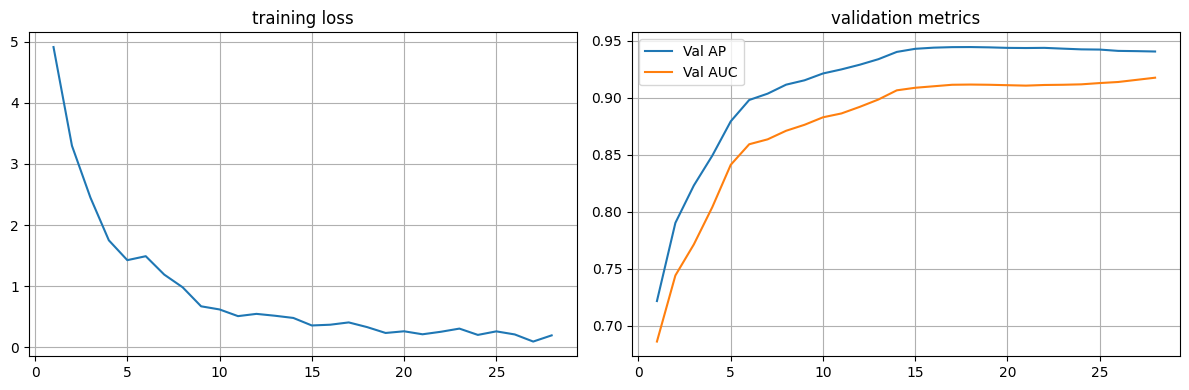

In [17]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses)
plt.title("training loss")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, val_aps, label="Val AP")
plt.plot(epochs, val_aucs, label="Val AUC")
plt.title("validation metrics")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [18]:
with open(f"{DATA_DIR}/processed/edge_splits/test_pos.pkl", "rb") as f:
    test_pos = pickle.load(f)

with open(f"{DATA_DIR}/processed/negative_samples/test_neg.pkl", "rb") as f:
    test_neg = pickle.load(f)

model.load_state_dict(torch.load("hetero_gat_best.pt"))

test_auc, test_ap = evaluate(test_pos, test_neg)

print(f"Test AUC: {test_auc:.4f}")
print(f"Test AP: {test_ap:.4f}")

Test AUC: 0.8868
Test AP: 0.8953


In [19]:
from torch_geometric.nn import HeteroConv, GATConv

class HeteroGAT_Attn(nn.Module):
    def __init__(self, hidden_dim, heads=4):
        super().__init__()

        self.conv1 = HeteroConv(
            {
                edge_type: GATConv(
                    (-1, -1),
                    hidden_dim,
                    heads=heads,
                    concat=True,
                    add_self_loops=False
                )
                for edge_type in train_data.edge_types
            },
            aggr="sum"
        )

        self.conv2 = HeteroConv(
            {
                edge_type: GATConv(
                    (-1, -1),
                    hidden_dim,
                    heads=1,
                    concat=False,
                    add_self_loops=False
                )
                for edge_type in train_data.edge_types
            },
            aggr="sum"
        )

    def forward(self, x_dict, edge_index_dict):

        out_dict = {}
        attention_dict = {}

        # Manually compute attention for conv1
        for edge_type, conv in self.conv1.convs.items():
            src_type, _, dst_type = edge_type

            x_src = x_dict[src_type]
            x_dst = x_dict[dst_type]
            edge_index = edge_index_dict[edge_type]

            out, (ei, alpha) = conv(
                (x_src, x_dst),
                edge_index,
                return_attention_weights=True
            )

            if dst_type not in out_dict:
                out_dict[dst_type] = out
            else:
                out_dict[dst_type] += out

            attention_dict[edge_type] = alpha.detach().cpu()

        # Apply activation + dropout
        for k in out_dict:
            out_dict[k] = F.dropout(F.elu(out_dict[k]), p=0.5, training=False)

        # Second layer normally
        out_dict = self.conv2(out_dict, edge_index_dict)

        return out_dict, attention_dict

In [20]:
attn_model = HeteroGAT_Attn(EMB_DIM, heads=HEADS).to(device)
attn_model.load_state_dict(torch.load("hetero_gat_best.pt"))
attn_model.eval()

print("Attention-enabled model loaded.")

Attention-enabled model loaded.


In [21]:
with torch.no_grad():
    _, attention_dict = attn_model(
        train_data.x_dict,
        train_data.edge_index_dict
    )

print("Attention extracted for relations:")
print(attention_dict.keys())

Attention extracted for relations:
dict_keys([('Compound', 'CtD', 'Disease'), ('Gene', 'GiG', 'Gene'), ('Disease', 'DdG', 'Gene'), ('Compound', 'CbG', 'Gene'), ('Compound', 'CuG', 'Gene'), ('Disease', 'DaG', 'Gene'), ('Gene', 'GcG', 'Gene'), ('Gene', 'Gr>G', 'Gene'), ('Compound', 'CdG', 'Gene'), ('Disease', 'DuG', 'Gene'), ('Disease', 'rev_CtD', 'Compound'), ('Gene', 'rev_DdG', 'Disease'), ('Gene', 'rev_CbG', 'Compound'), ('Gene', 'rev_CuG', 'Compound'), ('Gene', 'rev_DaG', 'Disease'), ('Gene', 'rev_CdG', 'Compound'), ('Gene', 'rev_DuG', 'Disease')])


In [22]:
relation_attention = {}

for edge_type, alpha in attention_dict.items():
    mean_attention = alpha.mean().item()
    relation_attention[edge_type] = mean_attention

for rel, score in sorted(
    relation_attention.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{rel}: {score:.4f}")

('Disease', 'DdG', 'Gene'): 0.7536
('Disease', 'DuG', 'Gene'): 0.7282
('Disease', 'DaG', 'Gene'): 0.4272
('Disease', 'rev_CtD', 'Compound'): 0.3588
('Compound', 'CuG', 'Gene'): 0.1731
('Compound', 'CtD', 'Disease'): 0.1676
('Compound', 'CbG', 'Gene'): 0.1460
('Compound', 'CdG', 'Gene'): 0.1365
('Gene', 'rev_CbG', 'Compound'): 0.1200
('Gene', 'GcG', 'Gene'): 0.1009
('Gene', 'GiG', 'Gene'): 0.0515
('Gene', 'rev_CuG', 'Compound'): 0.0375
('Gene', 'rev_CdG', 'Compound'): 0.0348
('Gene', 'Gr>G', 'Gene'): 0.0164
('Gene', 'rev_DaG', 'Disease'): 0.0106
('Gene', 'rev_DdG', 'Disease'): 0.0058
('Gene', 'rev_DuG', 'Disease'): 0.0057


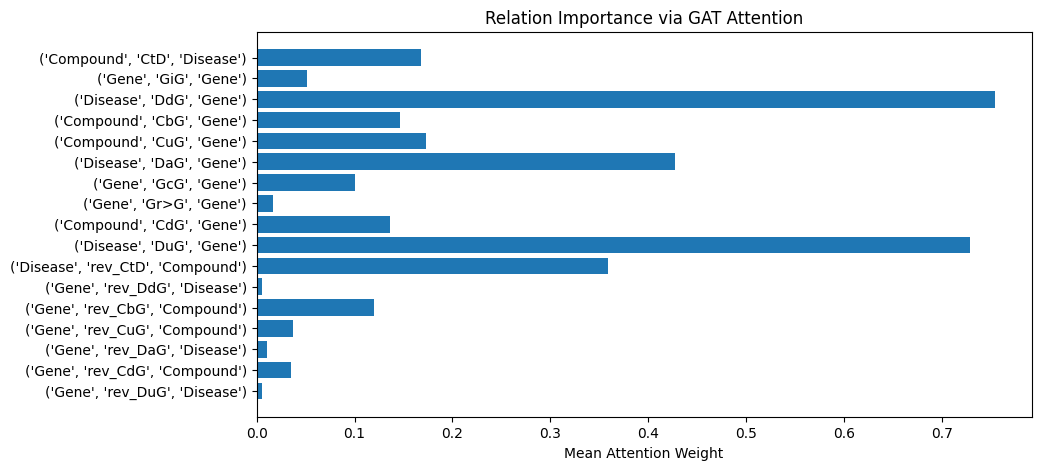

In [23]:
import matplotlib.pyplot as plt

relations = [str(r) for r in relation_attention.keys()]
scores = list(relation_attention.values())

plt.figure(figsize=(10, 5))
plt.barh(relations, scores)
plt.xlabel("Mean Attention Weight")
plt.title("Relation Importance via GAT Attention")
plt.gca().invert_yaxis()
plt.show()

In [24]:
import torch

# -------- Safe Embedding Extraction --------
@torch.no_grad()
def extract_embeddings(model, data):
    model.eval()

    output = model(data.x_dict, data.edge_index_dict)

    # Handle both cases:
    # - model returns z_dict
    # - model returns (z_dict, attention_dict)
    if isinstance(output, tuple):
        z = output[0]
    else:
        z = output

    return {
        "Compound": z["Compound"].cpu(),
        "Disease": z["Disease"].cpu(),
        "Gene": z["Gene"].cpu()
    }

# Extract embeddings
embeddings = extract_embeddings(model, train_data)

# -------- Build Artifact --------
gat_artifact = {
    "model_name": "HeteroGAT_regularized",
    "embedding_dim": EMB_DIM,
    "heads": HEADS,
    "dropout_layer1": 0.5,
    "dropout_layer2": 0.3,
    "weight_decay": 5e-4,
    "best_val_auc": max(val_aucs),
    "best_val_ap": max(val_aps),
    "test_auc": test_auc,
    "test_ap": test_ap,
    "train_losses": train_losses,
    "val_aucs": val_aucs,
    "val_aps": val_aps,
    "relation_attention": relation_attention,
    "embeddings": embeddings
}

# -------- Save --------
torch.save(gat_artifact, "hetero_gat_artifact.pt")

print("GAT artifact saved to hetero_gat_artifact.pt")

GAT artifact saved to hetero_gat_artifact.pt


In [27]:
SAVE_PATH = "/content/drive/MyDrive/drug_repurposing/models/"
torch.save(gat_artifact, SAVE_PATH + "hetero_gat_artifact.pt")

# VISUALIZATIONS

In [28]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

In [29]:
compound_emb = embeddings["Compound"].numpy()
disease_emb = embeddings["Disease"].numpy()

X = np.vstack([compound_emb, disease_emb])

labels = np.array(
    [0]*len(compound_emb) + [1]*len(disease_emb)
)

In [30]:
from sklearn.decomposition import PCA

X_pca = PCA(n_components=20).fit_transform(X)
X_2d = TSNE().fit_transform(X_pca)

In [31]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

X_2d = tsne.fit_transform(X)

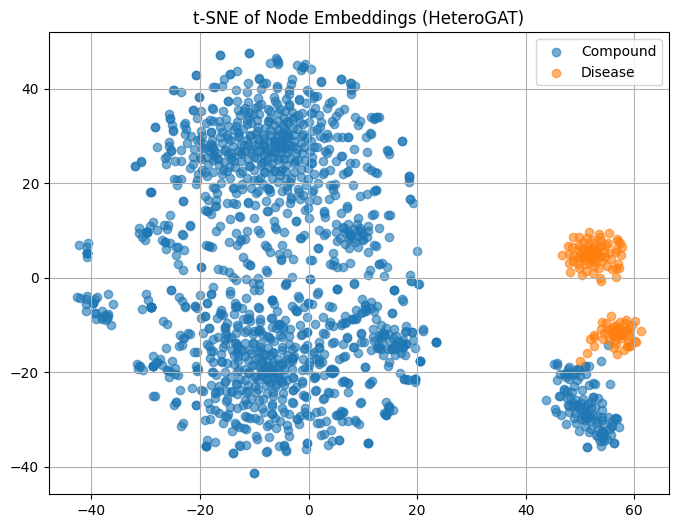

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(
    X_2d[labels==0, 0],
    X_2d[labels==0, 1],
    label="Compound",
    alpha=0.6
)

plt.scatter(
    X_2d[labels==1, 0],
    X_2d[labels==1, 1],
    label="Disease",
    alpha=0.6
)

plt.legend()
plt.title("t-SNE of Node Embeddings (HeteroGAT)")
plt.grid(True)
plt.show()

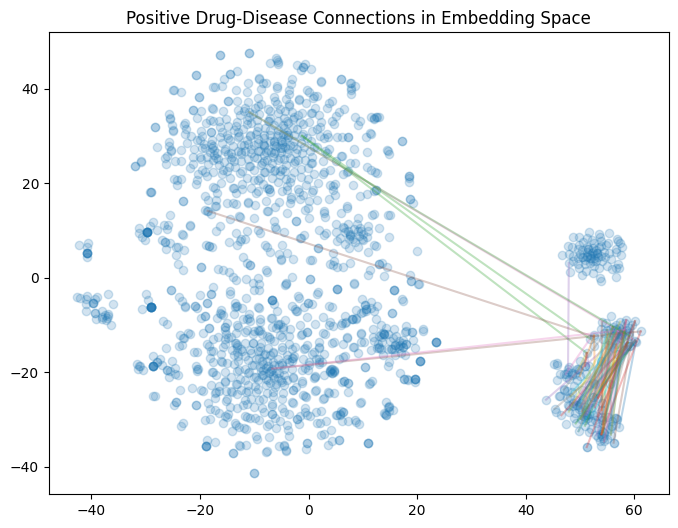

In [33]:
# Take a subset (important for clarity)
num_edges = 500
edges = test_pos[:num_edges]

plt.figure(figsize=(8,6))

# Plot all nodes
plt.scatter(X_2d[:,0], X_2d[:,1], alpha=0.2)

# Highlight edges
for e in edges:
    drug_idx = e[0]
    disease_idx = e[1] + len(compound_emb)  # shift index

    x1, y1 = X_2d[drug_idx]
    x2, y2 = X_2d[disease_idx]

    plt.plot([x1, x2], [y1, y2], alpha=0.3)

plt.title("Positive Drug-Disease Connections in Embedding Space")
plt.show()

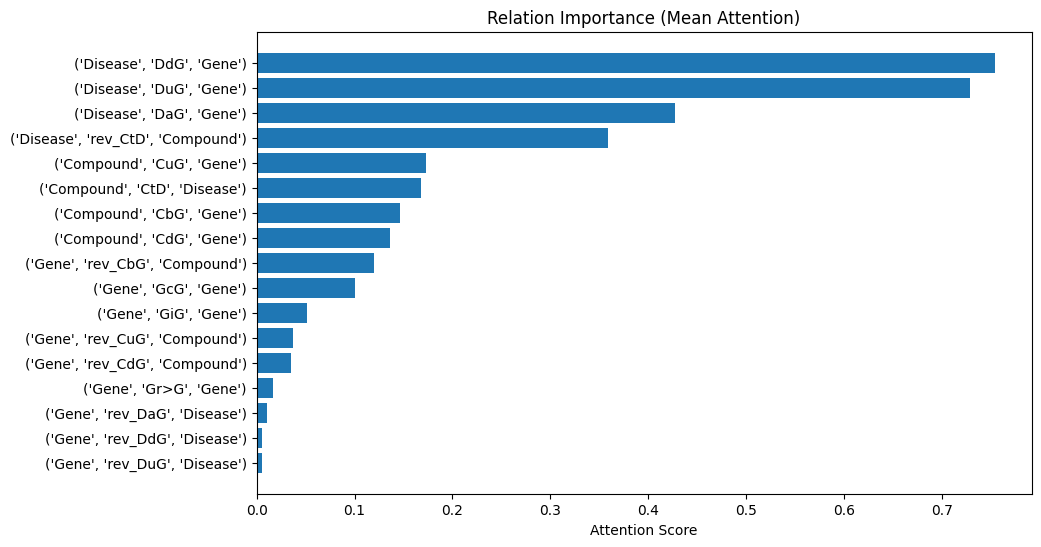

In [34]:
plt.figure(figsize=(10,6))

sorted_items = sorted(
    relation_attention.items(),
    key=lambda x: x[1]
)

relations = [str(k) for k,v in sorted_items]
scores = [v for k,v in sorted_items]

plt.barh(relations, scores)
plt.title("Relation Importance (Mean Attention)")
plt.xlabel("Attention Score")
plt.show()

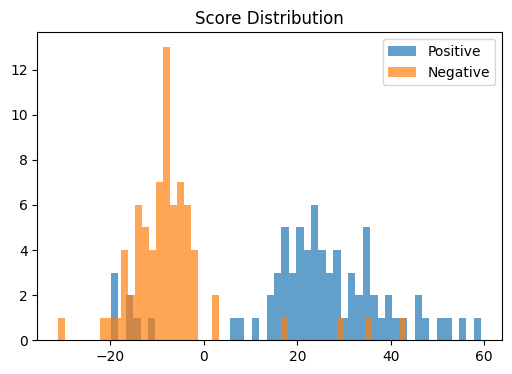

In [35]:
model.eval()

with torch.no_grad():
    z = model(train_data.x_dict, train_data.edge_index_dict)

pos_scores = dot_decoder(z["Compound"], z["Disease"], test_pos).cpu()
neg_scores = dot_decoder(z["Compound"], z["Disease"], test_neg).cpu()

plt.figure(figsize=(6,4))
plt.hist(pos_scores, bins=50, alpha=0.7, label="Positive")
plt.hist(neg_scores, bins=50, alpha=0.7, label="Negative")

plt.legend()
plt.title("Score Distribution")
plt.show()

# CASE STUDY

In [36]:
import pandas as pd

nodes = pd.read_csv(
    f"{DATA_DIR}/hetionet-v1.0-nodes.tsv",
    sep="\t"
)

print(nodes.head())
print(nodes["kind"].value_counts())

                        id                       name     kind
0  Anatomy::UBERON:0000002             uterine cervix  Anatomy
1  Anatomy::UBERON:0000004                       nose  Anatomy
2  Anatomy::UBERON:0000006        islet of Langerhans  Anatomy
3  Anatomy::UBERON:0000007            pituitary gland  Anatomy
4  Anatomy::UBERON:0000010  peripheral nervous system  Anatomy
kind
Gene                   20945
Biological Process     11381
Side Effect             5734
Molecular Function      2884
Pathway                 1822
Compound                1552
Cellular Component      1391
Symptom                  438
Anatomy                  402
Pharmacologic Class      345
Disease                  137
Name: count, dtype: int64


In [37]:
compound_nodes = nodes[nodes["kind"] == "Compound"]
disease_nodes = nodes[nodes["kind"] == "Disease"]

print("Compounds:", len(compound_nodes))
print("Diseases:", len(disease_nodes))

Compounds: 1552
Diseases: 137


In [38]:
compound_id_to_name = dict(
    zip(compound_nodes["id"], compound_nodes["name"])
)

disease_id_to_name = dict(
    zip(disease_nodes["id"], disease_nodes["name"])
)

In [39]:
print(train_data["Compound"])
print(train_data["Disease"])

{'num_nodes': 1441, 'x': tensor([[-0.3984,  0.3161,  0.1281,  ..., -1.4807, -1.1460,  1.4486],
        [ 1.1794, -0.1463,  0.1402,  ..., -1.1823,  1.4278,  0.9890],
        [-2.2990,  0.8940, -1.0641,  ...,  0.5564, -0.1836,  0.0384],
        ...,
        [-0.2701, -0.3343,  1.3770,  ...,  0.3823,  0.1014, -0.6399],
        [ 0.3238, -0.1300, -2.2831,  ...,  0.1018,  0.6254,  0.2711],
        [ 0.7778,  0.1499, -0.3140,  ...,  0.1545, -0.2483, -0.4620]],
       device='cuda:0', grad_fn=<ToCopyBackward0>)}
{'num_nodes': 134, 'x': tensor([[ 0.5635, -0.3993, -0.0769,  ...,  0.0470,  2.1418,  0.3143],
        [ 2.1484,  0.4020, -2.2878,  ...,  0.0751, -2.0633, -0.5405],
        [-1.4094,  0.5766,  0.2807,  ..., -0.0323, -0.6962,  0.8037],
        ...,
        [-1.0432, -0.1572, -1.1036,  ...,  0.1859, -0.8828,  0.2573],
        [ 0.1201, -2.2487, -0.1908,  ..., -1.3688, -0.9691,  1.5953],
        [-1.0114,  0.1205,  0.7729,  ..., -1.2806,  0.7746,  0.7348]],
       device='cuda:0', grad_fn

In [40]:
compound_nodes = nodes[nodes["kind"] == "Compound"].reset_index(drop=True)
disease_nodes = nodes[nodes["kind"] == "Disease"].reset_index(drop=True)

print(compound_nodes.head())
print(disease_nodes.head())

                  id          name      kind
0  Compound::DB00014     Goserelin  Compound
1  Compound::DB00035  Desmopressin  Compound
2  Compound::DB00050    Cetrorelix  Compound
3  Compound::DB00091  Cyclosporine  Compound
4  Compound::DB00093   Felypressin  Compound
                      id                           name     kind
0  Disease::DOID:0050156  idiopathic pulmonary fibrosis  Disease
1  Disease::DOID:0050425         restless legs syndrome  Disease
2  Disease::DOID:0050741             alcohol dependence  Disease
3  Disease::DOID:0050742            nicotine dependence  Disease
4  Disease::DOID:0060073        lymphatic system cancer  Disease


In [41]:
print("Graph compounds:", train_data["Compound"].num_nodes)
print("TSV compounds:", len(compound_nodes))

print("Graph diseases:", train_data["Disease"].num_nodes)
print("TSV diseases:", len(disease_nodes))

Graph compounds: 1441
TSV compounds: 1552
Graph diseases: 134
TSV diseases: 137


In [42]:
compound_idx_to_name = compound_nodes["name"].tolist()
disease_idx_to_name = disease_nodes["name"].tolist()

In [43]:
def get_drug_name(idx):
    if idx < len(compound_idx_to_name):
        return compound_idx_to_name[idx]
    return f"Drug_{idx}"

def get_disease_name(idx):
    if idx < len(disease_idx_to_name):
        return disease_idx_to_name[idx]
    return f"Disease_{idx}"

In [44]:
for i in range(5):
    print(i, get_drug_name(i))

for i in range(5):
    print(i, get_disease_name(i))

0 Goserelin
1 Desmopressin
2 Cetrorelix
3 Cyclosporine
4 Felypressin
0 idiopathic pulmonary fibrosis
1 restless legs syndrome
2 alcohol dependence
3 nicotine dependence
4 lymphatic system cancer


In [45]:
model.eval()

with torch.no_grad():
    z = model(train_data.x_dict, train_data.edge_index_dict)

compound_emb = z["Compound"]
disease_emb = z["Disease"]

# ---- Pick meaningful disease ----
for i in range(10):
    print(i, get_disease_name(i))

0 idiopathic pulmonary fibrosis
1 restless legs syndrome
2 alcohol dependence
3 nicotine dependence
4 lymphatic system cancer
5 pharynx cancer
6 duodenum cancer
7 ileum cancer
8 leprosy
9 prostate cancer


In [46]:
disease_id = 6  # change after checking names

print("\nDisease:", get_disease_name(disease_id))

scores = torch.matmul(compound_emb, disease_emb[disease_id])

K = 10
topk = torch.topk(scores, K)

print("\nTop predicted drugs:\n")

for i, idx in enumerate(topk.indices):
    print(
        f"Rank {i+1}: {get_drug_name(idx.item())} "
        f"| Score: {topk.values[i].item():.4f}"
    )


Disease: duodenum cancer

Top predicted drugs:

Rank 1: Goserelin | Score: 1.8244
Rank 2: Nortriptyline | Score: 1.3099
Rank 3: Indecainide | Score: 1.1358
Rank 4: Auranofin | Score: 1.1109
Rank 5: Dopamine | Score: 0.9834
Rank 6: Alfuzosin | Score: 0.9254
Rank 7: Desipramine | Score: 0.7279
Rank 8: Flurandrenolide | Score: 0.6985
Rank 9: Dihydroergotamine | Score: 0.5716
Rank 10: Pralatrexate | Score: 0.4386


In [47]:
train_pos_set = set((d, dis) for d, dis in train_pos)

for i, idx in enumerate(topk.indices):
    drug = idx.item()
    exists = (drug, disease_id) in train_pos_set

    print(
        f"{get_drug_name(drug)} "
        f"| Known: {exists}"
    )

Goserelin | Known: False
Nortriptyline | Known: False
Indecainide | Known: False
Auranofin | Known: False
Dopamine | Known: False
Alfuzosin | Known: False
Desipramine | Known: False
Flurandrenolide | Known: False
Dihydroergotamine | Known: False
Pralatrexate | Known: False
